# Adaptive clustering — threshold sweep, substructure diagnostic

Companion to `Adaptive_clustering.ipynb`. It exercises the sweep / diagnostic helpers in `src/adaptive_clustering.py`:

1. **2D hyperparameter sweep** over the full Cartesian product of `INERTIA_THRESHOLD` x `MERGE_DISTANCE_THRESHOLD` (both configurable at the top). For each pair it records final cluster count, cluster-size distribution, median assignment margin, %% low-margin sites, silhouette, and a bootstrap-ARI stability score. Results are collected into one dataframe, saved to two CSVs (`…_results.csv` and `…_parameters.csv` — the settings that produced them), filtered to acceptable pairs, ranked, and shown as heatmaps over the whole grid.
2. **Substructure diagnostic** for a single cluster: distance-to-centroid histogram, 1- vs 2-component Gaussian-mixture BIC, and a close-half vs far-half mean-shape comparison.

**Everything here is time-series-shape only** — no site metadata (ERK vs non-ERK, functional score, ...) feeds into the clustering or the scoring. A marked TODO for post-hoc Fisher enrichment is left at the end for when metadata is available.

**Normalization note:** the pipeline applies *no* per-site normalization (no z-scoring); `TimeSeriesKMeans(metric="euclidean")` clusters the raw `DATA_TYPE` magnitudes. So `result.centroids` and the member curves share one space, and all diagnostic axes are labelled with `DATA_TYPE` accordingly.

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.column_spec import ColumnSpec
from src.filters import filter_by_nreps, filter_dynamics
from src.adaptive_clustering import (
    adaptive_kmeans_clustering,
    sweep_thresholds,
    filter_and_rank_sweep,
    plot_sweep_heatmaps,
    diagnose_cluster_substructure,
)

In [149]:
# Clustering fills missing values with 0 (= no change from starve) by convention.
hme1_2 = pd.read_csv(
    "../../Experiment/hme1_2/Data/Processed/20260709_hTERT_HEM1_2_processed_phPlus.tsv",
    sep="\t", low_memory=False,
).fillna(0)
hme1_2.shape

(50002, 441)

## Parameters

Everything configurable lives here. The **two sweep ranges** are `INERTIA_THRESHOLDS` and `MERGE_DISTANCE_THRESHOLDS` — the sweep runs their full 2D product.

In [171]:
df_raw = hme1_2

# --- Dataset / columns --------------------------------------------------------
CELL_LINES   = ["WT"]
CONDITIONS   = ["_EGF_"]#, "_INS_", "_EGFnINS_"]
DATA_TYPE    = "log2:scaled"
EXCLUDE_FULL = True
STOICHIOMETRY = {"_EGF_": 1}#,  "_INS_": 1, "_EGFnINS_": 1}  # None to disable
TRANSPOSE     = True   # required when STOICHIOMETRY is not None

# --- Filtering ----------------------------------------------------------------
MIN_REPS = 2
MIN_FC   = 0.5

# --- Fixed adaptive-clustering knobs (held constant across the sweep) ----------
INITIAL_N_CLUSTERS     = 15 # 25
INERTIA_MODE           = "mean"   # 'total' | 'mean' | 'rms'
N_SUBCLUSTERS          = 3 # 2
MAX_SUBDIVISION_ROUNDS = 3
MIN_CLUSTER_SIZE       = 15       # never SPLIT clusters smaller than this
RANDOM_STATE           = 0

# --- Sweep grid (the two axes) ------------------------------------------------
INERTIA_THRESHOLDS        = [0.4, 0.6, 1.0] #  , 3.0,  1.5, 2.0, 2.5
MERGE_DISTANCE_THRESHOLDS = [0.2, 0.4, 0.6] # [0.6, 0.8, 1.0, 1.2, 1.5]

# --- Sweep scoring ------------------------------------------------------------
MARGIN_THRESHOLD       = 0.3 # 0.3      # 'low-confidence' assignment margin cutoff
COMPUTE_STABILITY      = True     # set False for a fast first pass (skips bootstrap)
N_BOOTSTRAP            = 10       # subsamples for the stability ARI
BOOTSTRAP_FRAC        = 0.9       # fraction of sites per subsample
SILHOUETTE_SAMPLE_SIZE = 2000     # sites sub-sampled for silhouette (speed)

# --- Filter of the sweep results ----------------------------------------------
MIN_CLUSTERS         = 10
MAX_CLUSTERS         = 40
MIN_SMALLEST_CLUSTER = 10         # smallest resulting cluster must have >= this many sites

# --- Derived — do not edit ----------------------------------------------------
_scan_cols   = ColumnSpec.select(df_raw, cell_lines=CELL_LINES, data_type=DATA_TYPE,
                                 conditions=CONDITIONS, exclude_full=EXCLUDE_FULL,
                                 exclude_replicate_cols=True)
N_DIMS       = len(CELL_LINES) * len(CONDITIONS)
N_TIMEPOINTS = len(_scan_cols) // N_DIMS
print(f"Columns: {len(_scan_cols)} | Dimensions: {N_DIMS} | Timepoints/condition: {N_TIMEPOINTS}")
print(f"Grid size: {len(INERTIA_THRESHOLDS)} x {len(MERGE_DISTANCE_THRESHOLDS)} = "
      f"{len(INERTIA_THRESHOLDS) * len(MERGE_DISTANCE_THRESHOLDS)} threshold pairs")

Columns: 6 | Dimensions: 1 | Timepoints/condition: 6
Grid size: 3 x 3 = 9 threshold pairs


## Filtering

Keep sites detected in enough replicates and with real dynamics, so clustering is driven by shape rather than flat/noisy profiles.

In [172]:
df_filtered = filter_by_nreps(df_raw, min_reps=MIN_REPS)
print(f"After n:reps >= {MIN_REPS}:  {df_filtered.shape[0]} sites")

df_filtered = filter_dynamics(
    df           = df_filtered,
    cell_lines   = CELL_LINES,
    conditions   = CONDITIONS,
    data_type    = DATA_TYPE,
    threshold    = MIN_FC,
    mode         = "extremes",
    exclude_full = EXCLUDE_FULL,
)
print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

After n:reps >= 2:  33719 sites
After |FC| >= 0.5:      32351 sites


## Run the 2D threshold sweep

Runs the full pipeline for every `(inertia_threshold, merge_distance_threshold)` pair.

**Runtime:** with `COMPUTE_STABILITY=True` each grid cell also re-runs the pipeline `N_BOOTSTRAP` times, so total fits ~= `n_pairs * (1 + N_BOOTSTRAP)`. For a first pass set `COMPUTE_STABILITY=False`.

In [173]:
sweep_df = sweep_thresholds(
    df                        = df_filtered,
    inertia_thresholds        = INERTIA_THRESHOLDS,
    merge_distance_thresholds = MERGE_DISTANCE_THRESHOLDS,
    data_type                 = DATA_TYPE,
    condition_for_clustering  = CONDITIONS,
    cell_lines                = CELL_LINES,
    df_dimensions             = N_DIMS,
    time_series_length        = N_TIMEPOINTS,
    exclude_full              = EXCLUDE_FULL,
    stoichiometry             = STOICHIOMETRY,
    transpose                 = TRANSPOSE,
    inertia_mode              = INERTIA_MODE,
    initial_n_clusters        = INITIAL_N_CLUSTERS,
    n_subclusters             = N_SUBCLUSTERS,
    max_subdivision_rounds    = MAX_SUBDIVISION_ROUNDS,
    min_cluster_size          = MIN_CLUSTER_SIZE,
    random_state              = RANDOM_STATE,
    margin_threshold          = MARGIN_THRESHOLD,
    compute_stability         = COMPUTE_STABILITY,
    n_bootstrap               = N_BOOTSTRAP,
    bootstrap_frac            = BOOTSTRAP_FRAC,
    silhouette_sample_size    = SILHOUETTE_SAMPLE_SIZE,
    verbose                   = True,
)
sweep_df

[1/9] inertia_threshold=0.4, merge_distance_threshold=0.2
[2/9] inertia_threshold=0.4, merge_distance_threshold=0.4
[3/9] inertia_threshold=0.4, merge_distance_threshold=0.6
[4/9] inertia_threshold=0.6, merge_distance_threshold=0.2
[5/9] inertia_threshold=0.6, merge_distance_threshold=0.4
[6/9] inertia_threshold=0.6, merge_distance_threshold=0.6
[7/9] inertia_threshold=1.0, merge_distance_threshold=0.2
[8/9] inertia_threshold=1.0, merge_distance_threshold=0.4
[9/9] inertia_threshold=1.0, merge_distance_threshold=0.6


,inertia_threshold,merge_distance_threshold,n_clusters,size_min,size_median,size_max,size_std,median_margin,pct_low_margin,silhouette,stability
0,0.4,0.2,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.634120
1,0.4,0.4,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.624367
2,0.4,0.6,10,1013,1972.5,13365,3562.867734,0.193035,71.472288,0.154957,0.651748
3,0.6,0.2,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.634450
4,0.6,0.4,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.624685
5,0.6,0.6,10,1013,1972.5,13365,3562.867734,0.193035,71.472288,0.154957,0.651786
6,1.0,0.2,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.634450
7,1.0,0.4,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.624685
8,1.0,0.6,10,1013,1972.5,13365,3562.867734,0.193035,71.472288,0.154957,0.651786


In [174]:
# Save the full unfiltered grid AND the parameters that produced it, as two CSVs
# sharing the same descriptive, dated prefix (never overwrite — bump the tag for a
# new run). The parameters file makes each result reproducible, since the
# sampling/testing settings drive the outcome.
SWEEP_PREFIX  = "./20260714_adaptive_sweep_hme1_2_EGF_6_scaled"
RESULTS_CSV   = f"{SWEEP_PREFIX}_results.csv"
PARAMS_CSV    = f"{SWEEP_PREFIX}_parameters.csv"

# All settings that affect the sampling / testing (converted to str so lists and
# dicts stay in a single cell each).
params_record = {
    "dataset_file"             : "hme1_2 (20260709_hTERT_HEM1_2_processed_phPlus.tsv)",
    "n_sites_after_filtering"  : df_filtered.shape[0],
    "CELL_LINES"               : CELL_LINES,
    "CONDITIONS"               : CONDITIONS,
    "DATA_TYPE"                : DATA_TYPE,
    "EXCLUDE_FULL"             : EXCLUDE_FULL,
    "STOICHIOMETRY"            : STOICHIOMETRY,
    "TRANSPOSE"                : TRANSPOSE,
    "MIN_REPS"                 : MIN_REPS,
    "MIN_FC"                   : MIN_FC,
    "INITIAL_N_CLUSTERS"       : INITIAL_N_CLUSTERS,
    "INERTIA_MODE"             : INERTIA_MODE,
    "N_SUBCLUSTERS"            : N_SUBCLUSTERS,
    "MAX_SUBDIVISION_ROUNDS"   : MAX_SUBDIVISION_ROUNDS,
    "MIN_CLUSTER_SIZE"         : MIN_CLUSTER_SIZE,
    "RANDOM_STATE"             : RANDOM_STATE,
    "INERTIA_THRESHOLDS"       : INERTIA_THRESHOLDS,
    "MERGE_DISTANCE_THRESHOLDS": MERGE_DISTANCE_THRESHOLDS,
    "MARGIN_THRESHOLD"         : MARGIN_THRESHOLD,
    "COMPUTE_STABILITY"        : COMPUTE_STABILITY,
    "N_BOOTSTRAP"              : N_BOOTSTRAP,
    "BOOTSTRAP_FRAC"           : BOOTSTRAP_FRAC,
    "SILHOUETTE_SAMPLE_SIZE"   : SILHOUETTE_SAMPLE_SIZE,
    "MIN_CLUSTERS"             : MIN_CLUSTERS,
    "MAX_CLUSTERS"             : MAX_CLUSTERS,
    "MIN_SMALLEST_CLUSTER"     : MIN_SMALLEST_CLUSTER,
    "N_DIMS"                   : N_DIMS,
    "N_TIMEPOINTS"             : N_TIMEPOINTS,
    "saved_at"                 : pd.Timestamp.now().isoformat(timespec="seconds"),
}
params_df = pd.DataFrame(
    [(k, str(v)) for k, v in params_record.items()],
    columns=["parameter", "value"],
)

sweep_df.to_csv(RESULTS_CSV, index=False)
params_df.to_csv(PARAMS_CSV, index=False)
print(f"Saved results:    {RESULTS_CSV}")
print(f"Saved parameters: {PARAMS_CSV}")

Saved results:    ./20260714_adaptive_sweep_hme1_2_EGF_6_scaled_results.csv
Saved parameters: ./20260714_adaptive_sweep_hme1_2_EGF_6_scaled_parameters.csv


## Filter and rank

Keep only pairs with final cluster count in `[MIN_CLUSTERS, MAX_CLUSTERS]` **and** smallest cluster >= `MIN_SMALLEST_CLUSTER`, then rank survivors by silhouette and stability (mean of per-metric ranks). If this is empty, loosen the criteria or widen the grid.

In [175]:
ranked = filter_and_rank_sweep(
    sweep_df,
    min_clusters         = MIN_CLUSTERS,
    max_clusters         = MAX_CLUSTERS,
    min_smallest_cluster = MIN_SMALLEST_CLUSTER,
    rank_by              = ("silhouette", "stability"),
)
if ranked.empty:
    print("No threshold pair satisfies the filter. Loosen MIN/MAX_CLUSTERS or "
          "MIN_SMALLEST_CLUSTER, or widen the sweep grid.")
else:
    print(f"{len(ranked)} pairs survived. Top candidates:")
ranked.head(10)

9 pairs survived. Top candidates:


,inertia_threshold,merge_distance_threshold,n_clusters,size_min,size_median,size_max,size_std,median_margin,pct_low_margin,silhouette,stability,silhouette_rank,stability_rank,mean_rank
3,0.6,0.2,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.634450,1.0,4.0,2.5
6,1.0,0.2,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.634450,1.0,4.0,2.5
0,0.4,0.2,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.634120,1.0,6.0,3.5
4,0.6,0.4,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.624685,1.0,7.0,4.0
7,1.0,0.4,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.624685,1.0,7.0,4.0
5,0.6,0.6,10,1013,1972.5,13365,3562.867734,0.193035,71.472288,0.154957,0.651786,7.0,1.0,4.0
8,1.0,0.6,10,1013,1972.5,13365,3562.867734,0.193035,71.472288,0.154957,0.651786,7.0,1.0,4.0
1,0.4,0.4,15,1013,2196.0,4981,1010.882747,0.137380,83.879942,0.161958,0.624367,1.0,9.0,5.0
2,0.4,0.6,10,1013,1972.5,13365,3562.867734,0.193035,71.472288,0.154957,0.651748,7.0,3.0,5.0


## Heatmaps of the whole grid

The full unfiltered landscape (not only the filtered winners): `inertia_threshold` on the y-axis, `merge_distance_threshold` on the x-axis.

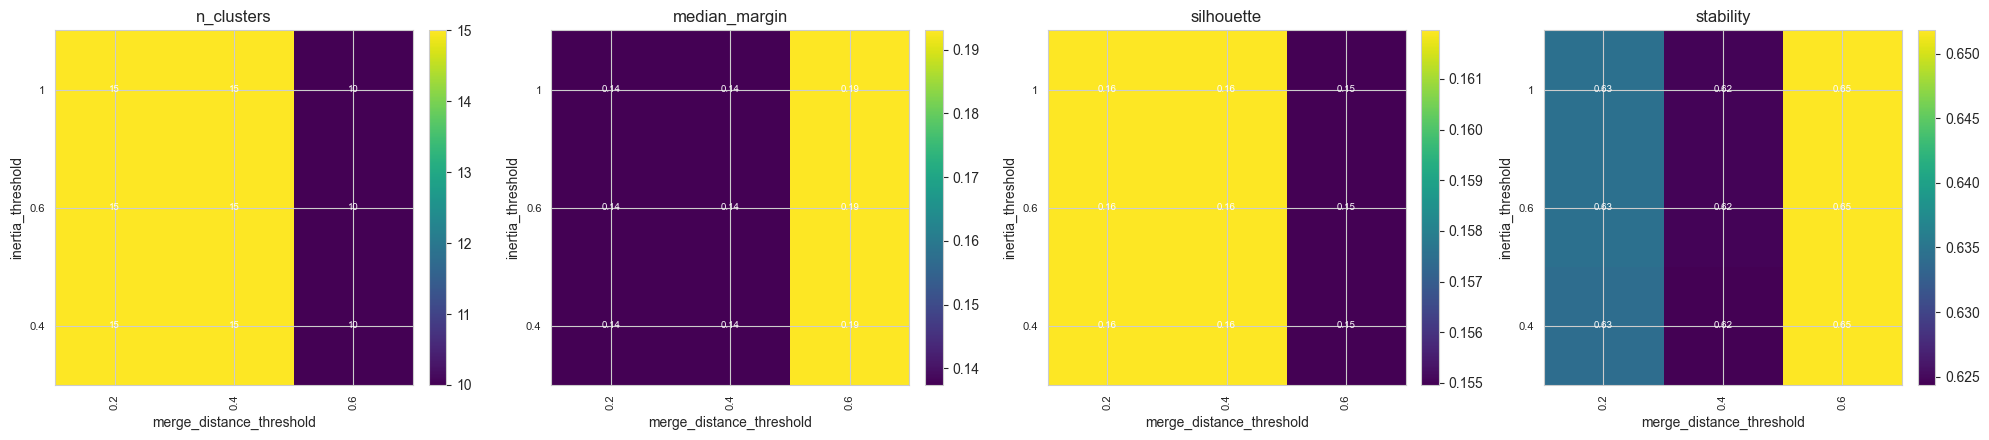

In [176]:
fig, axes = plot_sweep_heatmaps(
    sweep_df,
    metrics = ("n_clusters", "median_margin", "silhouette", "stability"),
)
plt.show()

## Substructure diagnostic

Pick a threshold pair (by default the top-ranked one, else edit `CHOSEN_INERTIA` / `CHOSEN_MERGE`), run the pipeline once, and inspect whether a cluster (default: the largest) hides two shapes.

The left panel is the distance-to-centroid histogram with 1- and 2-component Gaussian fits (a much lower 2-component BIC suggests sub-structure). The remaining panels compare, per condition, the cluster centroid against the mean of its **close** half vs its **far** half — all in the raw `DATA_TYPE` space the clustering used (no normalization).

In [177]:
# Choose thresholds: top-ranked pair if available, else set manually.
if not ranked.empty:
    CHOSEN_INERTIA = float(ranked.iloc[0]["inertia_threshold"])
    CHOSEN_MERGE   = float(ranked.iloc[0]["merge_distance_threshold"])
else:
    CHOSEN_INERTIA = 2.0
    CHOSEN_MERGE   = 1.0
print(f"Using inertia_threshold={CHOSEN_INERTIA}, merge_distance_threshold={CHOSEN_MERGE}")

df_clustered, result = adaptive_kmeans_clustering(
    df_filtered.copy(),
    data_type                = DATA_TYPE,
    condition_for_clustering = CONDITIONS,
    cell_lines               = CELL_LINES,
    exclude_full             = EXCLUDE_FULL,
    stoichiometry            = STOICHIOMETRY,
    transpose                = TRANSPOSE,
    inertia_threshold        = CHOSEN_INERTIA,
    merge_distance_threshold = CHOSEN_MERGE,
    inertia_mode             = INERTIA_MODE,
    initial_n_clusters       = INITIAL_N_CLUSTERS,
    n_subclusters            = N_SUBCLUSTERS,
    max_subdivision_rounds   = MAX_SUBDIVISION_ROUNDS,
    min_cluster_size         = MIN_CLUSTER_SIZE,
    df_dimensions            = N_DIMS,
    time_series_length       = N_TIMEPOINTS,
    random_state             = RANDOM_STATE,
    verbose                  = False,
    testing                  = True,
)

# Largest cluster by membership.
largest = max(result.cluster_sizes, key=result.cluster_sizes.get)
print(f"Largest cluster: {largest} ({result.cluster_sizes[largest]} sites)")

Using inertia_threshold=0.6, merge_distance_threshold=0.2
Largest cluster: 8 (4981 sites)


Cluster 8: 4981 members
  BIC (1 component): -8627.7
  BIC (2 components): -8973.1
  Preferred: 2 component(s) (sub-structure likely)


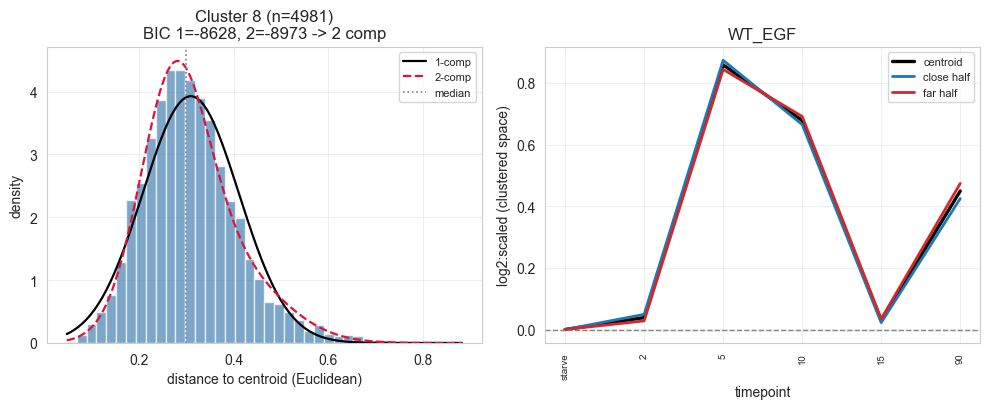

BIC 1-comp=-8627.7  2-comp=-8973.1  -> preferred 2 component(s)


In [178]:
# Inspect the largest cluster (change `largest` to any cluster label to inspect others).
diag = diagnose_cluster_substructure(result, cluster_label=largest)
plt.show()
print(f"BIC 1-comp={diag['bic_1']:.1f}  2-comp={diag['bic_2']:.1f}  "
      f"-> preferred {diag['preferred_n_components']} component(s)")

 Plot not saved


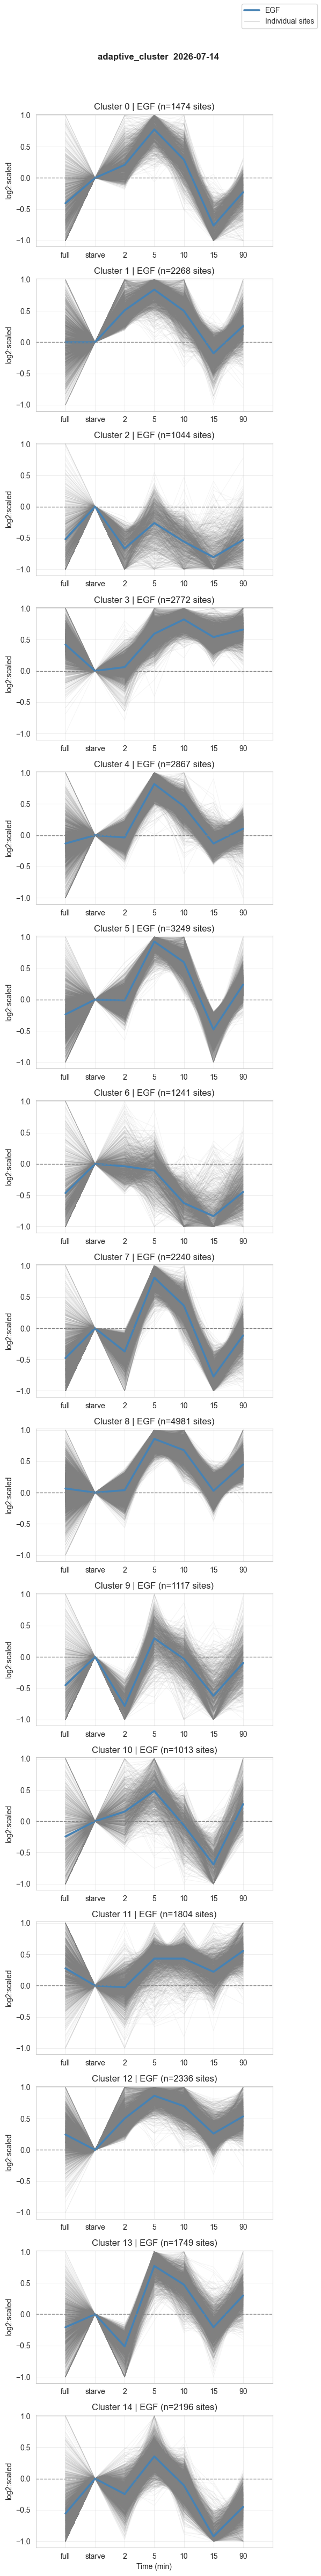

In [179]:
from src.clustering import cluster_similarity_per_condition
from src.plotting_functions import (
    clusters_plot_linear_mutants,
    plot_cluster_scores,
    plot_cluster_assignment_qc,
)
clusters_plot_linear_mutants(df_clustered,
                             cluster_column='adaptive_cluster',
                             data_type = DATA_TYPE, # "log2:FC"
                             cell_lines = CELL_LINES,
                             panel_by= 'condition',
                             conditions=CONDITIONS,
                             plot_different_data=True)

## Cluster quality — within-cluster Euclidean dispersion


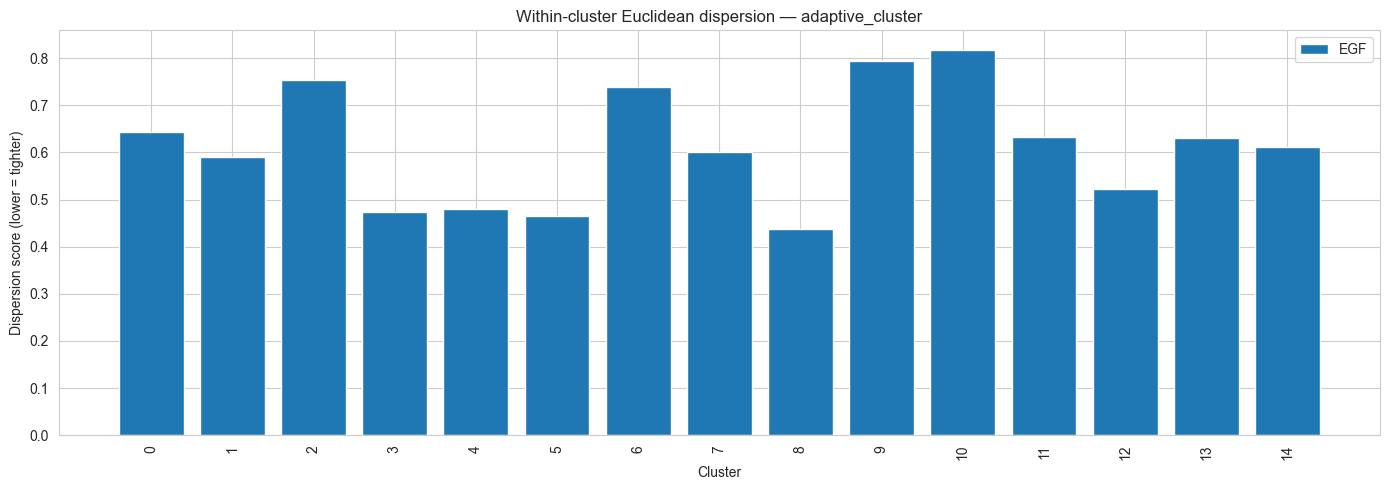

In [180]:
CLUSTER_COL = "adaptive_cluster"
scores = cluster_similarity_per_condition(
    df                  = df_clustered,
    cell_lines          = CELL_LINES,
    conditions          = CONDITIONS,
    data_type           = DATA_TYPE,
    cluster_column_name = CLUSTER_COL,
    exclude_full        = EXCLUDE_FULL,
    transpose           = True,
    metric              = "euclidean",
)
fig, ax = plot_cluster_scores(
    scores,
    cond_order = [c.strip("_") for c in CONDITIONS],
    title      = f"Within-cluster Euclidean dispersion — {CLUSTER_COL}",
)
plt.show()

## Assignment confidence

Four views of how confidently each site was assigned to its cluster, using the **Euclidean** distance from each site to every final cluster centroid (the adaptive-clustering analogue of the DTW `barycenters` matrix from `tslearn_clustering_KMeans`):

- **Distance-to-centroid heatmap** — rows are sites (sorted by cluster), columns are clusters; the assigned cluster should be the darkest cell in each row.
- **UMAP** — 2-D embedding of the distance-to-centroid matrix coloured by cluster; tight, well-separated blobs indicate clean assignments.
- **Margin histogram** — margin = (2nd-best distance) − (best distance); higher margin = more confident assignment. The orange line marks the 25th percentile (low-confidence sites).
- **Margin per cluster (boxplot)** — reveals which clusters are internally tight vs. ambiguous.

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


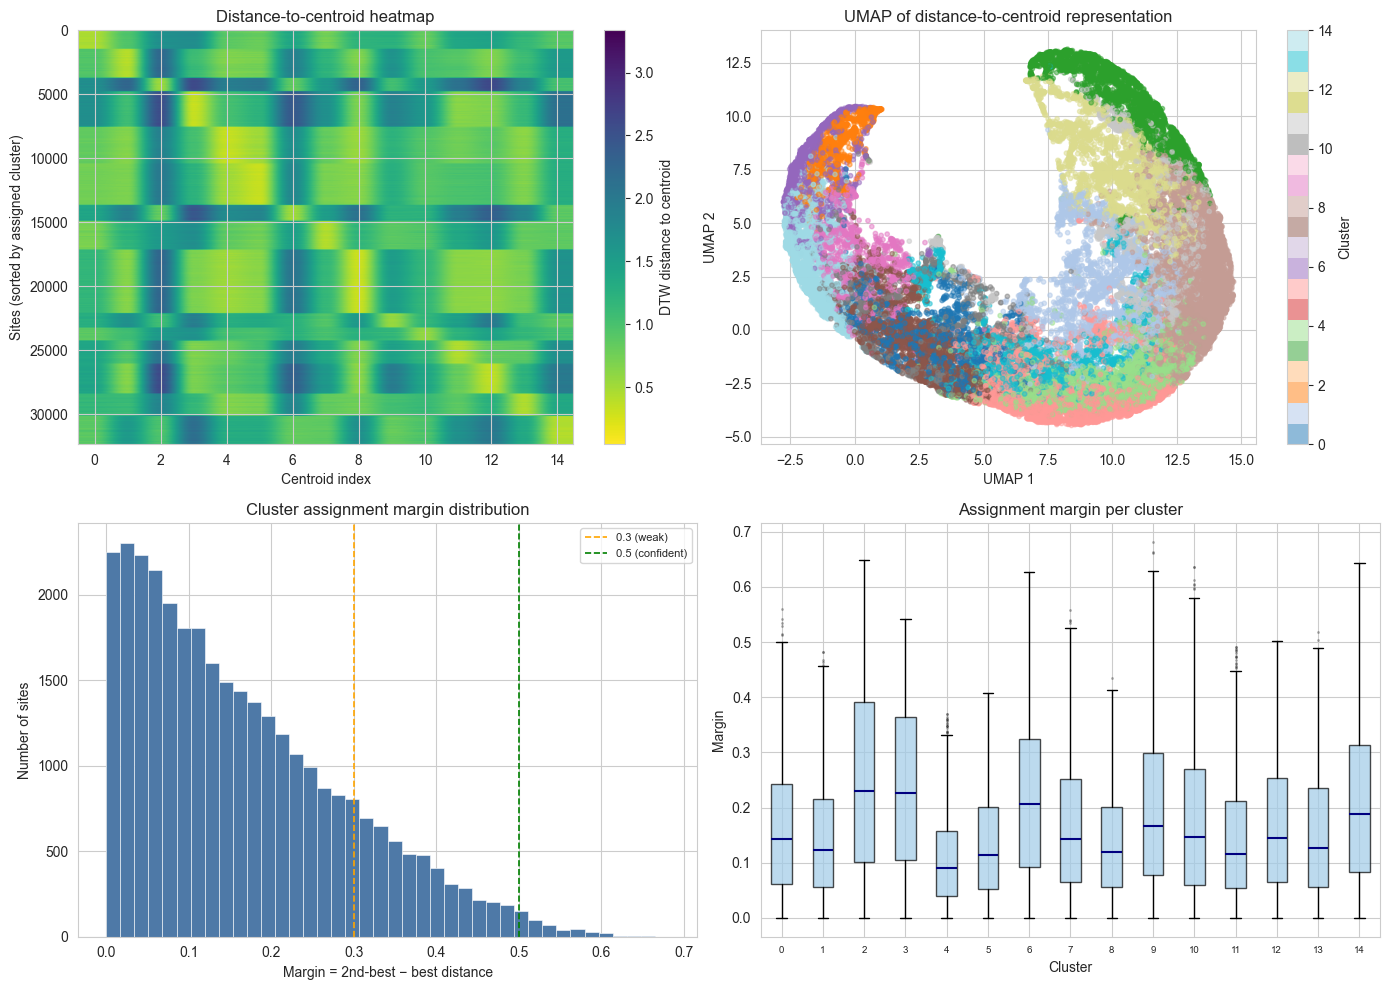

In [181]:
from scipy.spatial.distance import cdist
# Euclidean distance from each site to every final cluster centroid.
# result.centroids is (n_clusters x n_features) in the flattened feature space;
# result.X is the reshaped multivariate array. cdist gives the (n_sites x n_clusters)
# distance-to-centroid matrix that plot_cluster_assignment_qc expects.
X_flat = result.X.reshape(result.X.shape[0], -1)
dist_to_centroid = cdist(X_flat, result.centroids, metric="euclidean")

fig, axes = plot_cluster_assignment_qc(dist_to_centroid, result.labels)
plt.show()

2## next step — post-hoc enrichment (Fisher's exact test)

**Placeholder for a later step, once site metadata is available.** Clustering and threshold selection above are deliberately kept **time-series-shape only** — no metadata (ERK vs non-ERK motif, functional score, known regulatory role) influences the clustering or the sweep scoring.

Once metadata is joined onto the clustered dataframe, test each cluster for enrichment of a categorical annotation with a per-cluster 2x2 Fisher's exact test + multiple-testing correction. The stub `posthoc_enrichment_fisher` in `src/adaptive_clustering.py` documents the intended contingency table and output; implement it there when ready.

In [61]:
# Next work (post-hoc, metadata-dependent — do NOT feed metadata back into clustering):
#
# from scipy.stats import fisher_exact
# from statsmodels.stats.multitest import multipletests
#
# ANNOTATION_COL = "ERK_motif"   # e.g. a boolean/categorical metadata column
# results = []
# annotated = df_clustered[ANNOTATION_COL].astype(bool)
# for c in sorted(df_clustered[CLUSTER_COL].unique()):
#     in_c = df_clustered[CLUSTER_COL] == c
#     table = [[( in_c &  annotated).sum(), ( in_c & ~annotated).sum()],
#              [(~in_c &  annotated).sum(), (~in_c & ~annotated).sum()]]
#     odds, p = fisher_exact(table, alternative="greater")
#     results.append({"cluster": c, "odds_ratio": odds, "p_value": p})
# enr = pd.DataFrame(results)
# enr["q_value"] = multipletests(enr["p_value"], method="fdr_bh")[1]
# enr.sort_values("q_value")
pass